In [88]:
from typing import Callable
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import supervision as sv
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision import datasets, transforms
from torchinfo import summary


Definimos la arquitectura de nuestra red neuronal: Perceptron multicapa

In [22]:
# Perceptron multicapa (fully connected network (FCN))
class TwoLayerFCN(nn.Module):
    """
    Parametrized implementation of a simple fully connected neural network. 
    """
    def __init__(
        self, 
        n_inputs: int,
        n_outputs: int,
        hidden_size: int = 128, 
        activation: Callable = nn.ReLU
    ):
        """
        Parameters
        ----------
        n_inputs : int
            Number of input features.
        n_outputs : int
            Number of output classes.
        activation : Callable
            Activation function to use in the hidden layer. Default is ReLU. 
            Check PyTorch documentation for other options 
            https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity.
        """
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, hidden_size) 
        self.activation = activation()
        self.output_layer = nn.Linear(hidden_size, n_outputs)

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

Instanciamos un modelo simple y analizamos su estructura

In [28]:
model = TwoLayerFCN(n_inputs=2, n_outputs=2, hidden_size=4, activation=nn.ReLU)

# Resumen de la arquitectura del modelo con torchinfo (pip install torchinfo)
print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 2)))

# Visualizar arquitectura sin instalar torchinfo
def print_model_summary(model, input_size):
    print(model)
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")
print(' --- Custom summary: ---')
print_model_summary(model, input_size=(1, 2))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
TwoLayerFCN                              [1, 2]                    --
├─Linear: 1-1                            [1, 4]                    12
├─ReLU: 1-2                              [1, 4]                    --
├─Linear: 1-3                            [1, 2]                    10
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
 --- Custom summary: ---
TwoLayerFCN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (activation): ReLU()
  (output_layer): Linear(in_features=4, out_features=2, bias=True)
)
Number of parameters: 22


Conociendo el dataset

In [46]:
# Descargamos el dataset MNIST
train_dataset = datasets.MNIST(root='.', train=True, download=True)

# El dataset es una lista de tuplas (imagen, etiqueta)
print(type(train_dataset[0]))
print(f'Primer elemento del dataset: {train_dataset[0]}')  # Imprime el primer elemento del dataset
print(f'Cantidad de imagenes: {len(train_dataset)}')  # Número de imágenes en el dataset

<class 'tuple'>
Primer elemento del dataset: (<PIL.Image.Image image mode=L size=28x28 at 0x346598AC0>, 5)
Cantidad de imagenes: 60000


Data label 5


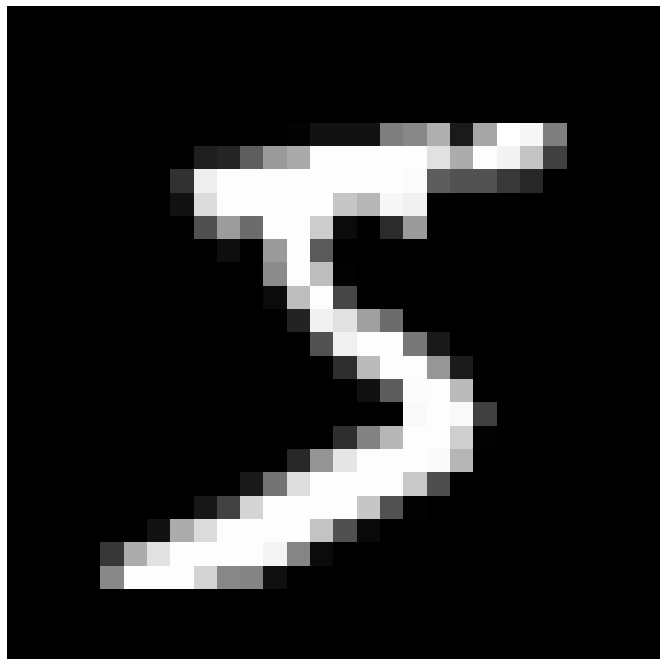

In [47]:
# visualizamos el primer elemento del dataset
image, label = train_dataset[0]
print(f'Data label {label}')
sv.plot_image(image)

# Entrenamiento

## Preparamos los datos

In [55]:
# Primero llevamos el dataset a un formato tensorial comun a todos los modelos 
# de PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte la imagen a un tensor
    transforms.Lambda(lambda x: x.view(-1))  # Flatten 28x28 to 784)  # Normaliza la imagen
])
# Reinstanciamos el dataset con la transformacion
train_dataset = datasets.MNIST(root='.', train=True, download=True, transform=transform)

# Como tenemos un modelo pequeño, vamos a usar un subset de n_samples del dataset
n_samples = 1000
train_subset = Subset(train_dataset, range(n_samples))
# Creamos un DataLoader para iterar sobre el dataset
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)

## Redefinimos el modelo

In [85]:
model = TwoLayerFCN(
    n_inputs=784, # 28x28 = 784 pixeles por imagen (las imagenes estan en gray)
    n_outputs=10, # clases en MNIST (nums del 0 al 9 codificados )
    hidden_size=128, # Tamaño de la capa oculta (la elegimos arbitrariamente)
    activation=nn.ReLU # Función de activación ReLU (eleccion arbitraria)
) 

## Loop de entrenamiento y recoleccion de metricas

In [86]:
N_EPOCHS = 50

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Variables para guardar las metricas
train_loss_avg = list()

#  Training loop
for epoch in range(N_EPOCHS):
    print(f"Running epoch {epoch+1}...")
    train_loss_avg.append(0)
    num_batches = 0
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # me guardo las metricas
        train_loss_avg[-1] += loss.item()
        num_batches += 1

    # Al final de cada epoch, guardo el promedio de la loss    
    train_loss_avg[-1] /= num_batches
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Running epoch 1...


100%|██████████| 125/125 [00:00<00:00, 709.74it/s]


Epoch 1, Loss: 0.5729
Running epoch 2...


100%|██████████| 125/125 [00:00<00:00, 1030.10it/s]


Epoch 2, Loss: 0.0880
Running epoch 3...


...

Epoch 48, Loss: 0.0004
Running epoch 49...


100%|██████████| 125/125 [00:00<00:00, 780.74it/s]


Epoch 49, Loss: 0.0009
Running epoch 50...


100%|██████████| 125/125 [00:00<00:00, 753.54it/s]

Epoch 50, Loss: 0.0005


# Graficamos metricas de entrenamiento

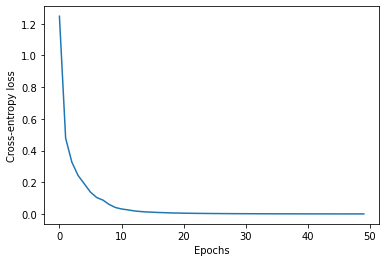

In [87]:
plt.figure()
plt.plot(train_loss_avg)
plt.xlabel('Epochs')
plt.ylabel('Cross-entropy loss')
plt.show()

raw logits tensor([[ -2.9632, -19.9529,   1.5973, -12.2606,   4.9705,  -5.0140,   0.3560,
          -6.6063,  -9.4162,  -2.3833]])
Probabilities: tensor([[3.4295e-04, 1.4344e-11, 3.2795e-02, 3.1434e-08, 9.5672e-01, 4.4112e-05,
         9.4786e-03, 8.9754e-06, 5.4043e-07, 6.1246e-04]])
Predicted class: 4, True class: 4


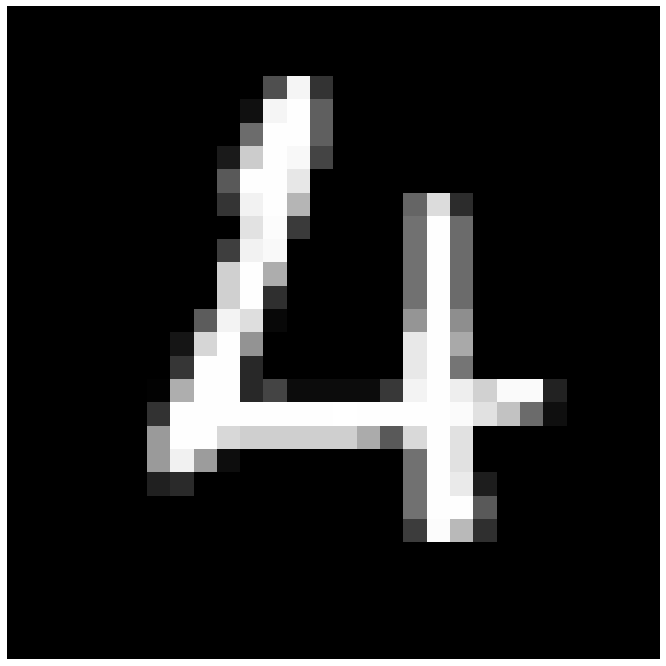

In [100]:
# Ejemplo de inferencia
model.eval()
with torch.no_grad():
    # Tomamos el primer elemento del dataset de entrenamiento
    image, label = train_dataset[1050]
    # Añadimos una dimensión para el batch size (1, 784)
    image = image.unsqueeze(0)
    # Pasamos la imagen por el modelo
    output = model(image)
    # Obtenemos la clase predicha
    print(f'raw logits {output}')

    # Podemos convertir los logits a probabilidades usando softmax
    probabilities = torch.softmax(output, dim=1)
    print(f'Probabilities: {probabilities}')
    
    predicted_class = torch.argmax(output, dim=1).item()
    print(f'Predicted class: {predicted_class}, True class: {label}')

    sv.plot_image(image.squeeze().view(28, 28))

Evaluamos el modelo en datos que no fueron usados en el entrenamiento

In [102]:
# Descargamos el dataset de test y creamos el dataloader

test_dataset = datasets.MNIST(root='.', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Evaluation loop
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8863
